# OR Window Breakout Close Direction Validation

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, Markdown, display

from src.analytics.or_window_breakout_close_direction_campaign import (
    build_direct_answers,
    render_direct_answers_markdown,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)


## 1) Charger les exports

In [2]:
OUTPUT_ROOT = Path(r"D:/Business/Trading/VSCODE/algo-trading-intraday-research/export/or_window_close_breakout_direction_campaign")
RESULTS_PATH = OUTPUT_ROOT / "breakout_close_direction_results.csv"
DAY_LEVEL_PATH = OUTPUT_ROOT / "breakout_close_direction_day_level.csv"
SANITY_PATH = OUTPUT_ROOT / "breakout_close_direction_data_sanity.csv"
SUMMARY_PATH = OUTPUT_ROOT / "breakout_close_direction_summary.md"
CHARTS_DIR = OUTPUT_ROOT / "charts"

results = pd.read_csv(RESULTS_PATH)
day_level = pd.read_csv(DAY_LEVEL_PATH, parse_dates=["session_date", "breakout_timestamp", "close_reference_timestamp"])
data_sanity = pd.read_csv(SANITY_PATH, parse_dates=["first_timestamp", "last_timestamp"])

print("OUTPUT_ROOT =", OUTPUT_ROOT)
print("RESULTS_PATH =", RESULTS_PATH)
print("DAY_LEVEL_PATH =", DAY_LEVEL_PATH)
print("SANITY_PATH =", SANITY_PATH)
print("SUMMARY_PATH =", SUMMARY_PATH)


OUTPUT_ROOT = D:\Business\Trading\VSCODE\algo-trading-intraday-research\export\or_window_close_breakout_direction_campaign
RESULTS_PATH = D:\Business\Trading\VSCODE\algo-trading-intraday-research\export\or_window_close_breakout_direction_campaign\breakout_close_direction_results.csv
DAY_LEVEL_PATH = D:\Business\Trading\VSCODE\algo-trading-intraday-research\export\or_window_close_breakout_direction_campaign\breakout_close_direction_day_level.csv
SANITY_PATH = D:\Business\Trading\VSCODE\algo-trading-intraday-research\export\or_window_close_breakout_direction_campaign\breakout_close_direction_data_sanity.csv
SUMMARY_PATH = D:\Business\Trading\VSCODE\algo-trading-intraday-research\export\or_window_close_breakout_direction_campaign\breakout_close_direction_summary.md


## 2) Tableaux recapitulatifs

In [3]:
display(Markdown("### Data sanity"))
display(data_sanity)

summary_cols = [
    "asset",
    "or_window_minutes",
    "n_days",
    "n_valid_breakouts",
    "hit_rate",
    "hit_rate_up",
    "hit_rate_down",
    "pct_no_breakout",
    "avg_close_extension",
    "median_close_extension",
]
display(Markdown("### Resultats detailles"))
display(results[summary_cols].sort_values(["asset", "or_window_minutes"]))

for metric in ["hit_rate", "hit_rate_up", "hit_rate_down", "pct_no_breakout", "n_valid_breakouts", "avg_close_extension"]:
    pivot = (
        results.pivot(index="asset", columns="or_window_minutes", values=metric)
        .reindex(index=["MES", "MNQ", "MGC", "M2K"], columns=[5, 15, 30, 60])
    )
    display(Markdown(f"### Pivot `{metric}`"))
    display(pivot)


### Data sanity

,asset,or_window_minutes,dataset_path,first_timestamp,last_timestamp,timezone,n_rth_sessions_total,median_rth_bars,n_sessions_exact_1600,n_sessions_close_proxy_1555_plus,n_complete_opening_range,n_eligible_days,n_excluded_incomplete_opening_range,n_excluded_no_close_proxy,pct_eligible_days
0,M2K,5,M2K_c_0_1m_20260322_134808.parquet,2019-05-05 18:01:00-04:00,2026-03-20 09:29:00-04:00,America/New_York,1747,391.0,1682,1684,1737,1679,10,58,0.961076
1,M2K,15,M2K_c_0_1m_20260322_134808.parquet,2019-05-05 18:01:00-04:00,2026-03-20 09:29:00-04:00,America/New_York,1747,391.0,1682,1684,1733,1675,14,58,0.958786
2,M2K,30,M2K_c_0_1m_20260322_134808.parquet,2019-05-05 18:01:00-04:00,2026-03-20 09:29:00-04:00,America/New_York,1747,391.0,1682,1684,1727,1670,20,57,0.955924
3,M2K,60,M2K_c_0_1m_20260322_134808.parquet,2019-05-05 18:01:00-04:00,2026-03-20 09:29:00-04:00,America/New_York,1747,391.0,1682,1684,1707,1661,40,46,0.950773
4,MES,5,MES_c_0_1m_20260322_135702.parquet,2019-05-05 18:00:00-04:00,2026-03-20 09:29:00-04:00,America/New_York,1747,391.0,1684,1684,1746,1683,1,63,0.963366
5,MES,15,MES_c_0_1m_20260322_135702.parquet,2019-05-05 18:00:00-04:00,2026-03-20 09:29:00-04:00,America/New_York,1747,391.0,1684,1684,1744,1681,3,63,0.962221
6,MES,30,MES_c_0_1m_20260322_135702.parquet,2019-05-05 18:00:00-04:00,2026-03-20 09:29:00-04:00,America/New_York,1747,391.0,1684,1684,1743,1681,4,62,0.962221
7,MES,60,MES_c_0_1m_20260322_135702.parquet,2019-05-05 18:00:00-04:00,2026-03-20 09:29:00-04:00,America/New_York,1747,391.0,1684,1684,1736,1679,11,57,0.961076
8,MGC,5,MGC_c_0_1m_20260322_155729.parquet,2010-10-03 19:26:00-04:00,2026-03-20 16:59:00-04:00,America/New_York,3128,141.0,1303,1866,1224,1168,1904,56,0.373402
9,MGC,15,MGC_c_0_1m_20260322_155729.parquet,2010-10-03 19:26:00-04:00,2026-03-20 16:59:00-04:00,America/New_York,3128,141.0,1303,1866,1000,966,2128,34,0.308824


### Resultats detailles

,asset,or_window_minutes,n_days,n_valid_breakouts,hit_rate,hit_rate_up,hit_rate_down,pct_no_breakout,avg_close_extension,median_close_extension
0,M2K,5,1679,1678,0.533969,0.543641,0.525114,0.000596,0.964124,1.700
1,M2K,15,1675,1669,0.536249,0.560680,0.512426,0.003582,0.950509,1.500
2,M2K,30,1670,1648,0.543689,0.554070,0.533333,0.013174,1.135801,1.600
3,M2K,60,1661,1534,0.548892,0.582361,0.515072,0.076460,0.937940,1.300
4,MES,5,1683,1683,0.533571,0.575472,0.491018,0.000000,2.311200,2.250
5,MES,15,1681,1680,0.535714,0.580831,0.487715,0.000595,1.673065,2.500
6,MES,30,1681,1676,0.538186,0.578652,0.492366,0.002974,1.918407,2.125
7,MES,60,1679,1626,0.532595,0.563429,0.496671,0.031566,1.502614,1.750
8,MGC,5,1168,1168,0.493151,0.513699,0.472603,0.000000,0.537842,-0.050
9,MGC,15,966,961,0.532778,0.552632,0.511777,0.005176,1.022060,0.600


### Pivot `hit_rate`

...

or_window_minutes,5,15,30,60
asset,,,,
MES,0.000000,0.000595,0.002974,0.031566
MNQ,0.000000,0.001190,0.008929,0.045888
MGC,0.000000,0.005176,0.019953,0.081946
M2K,0.000596,0.003582,0.013174,0.076460


### Pivot `n_valid_breakouts`

or_window_minutes,5,15,30,60
asset,,,,
MES,1683,1680,1676,1626
MNQ,1682,1679,1665,1601
MGC,1168,961,835,717
M2K,1678,1669,1648,1534


### Pivot `avg_close_extension`

or_window_minutes,5,15,30,60
asset,,,,
MES,2.311200,1.673065,1.918407,1.502614
MNQ,8.453775,7.595890,9.419670,8.143504
MGC,0.537842,1.022060,1.417006,1.386192
M2K,0.964124,0.950509,1.135801,0.937940


## 3) Heatmaps

### heatmap_hit_rate.png

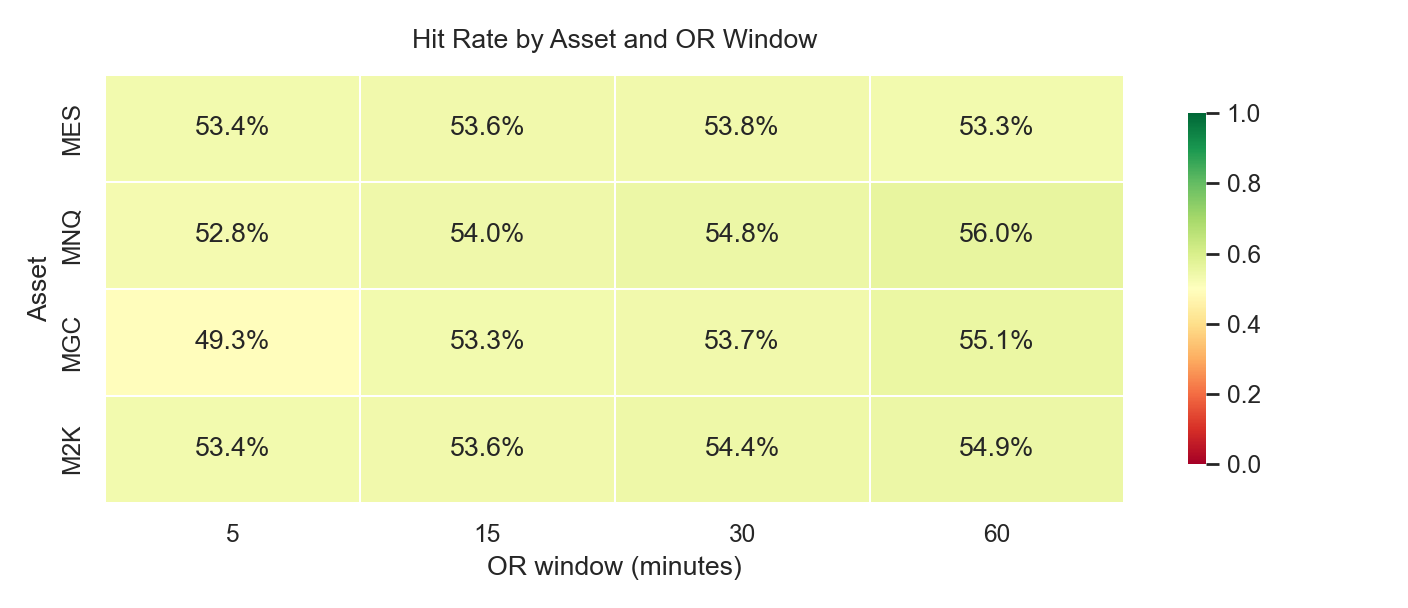

### heatmap_hit_rate_up.png

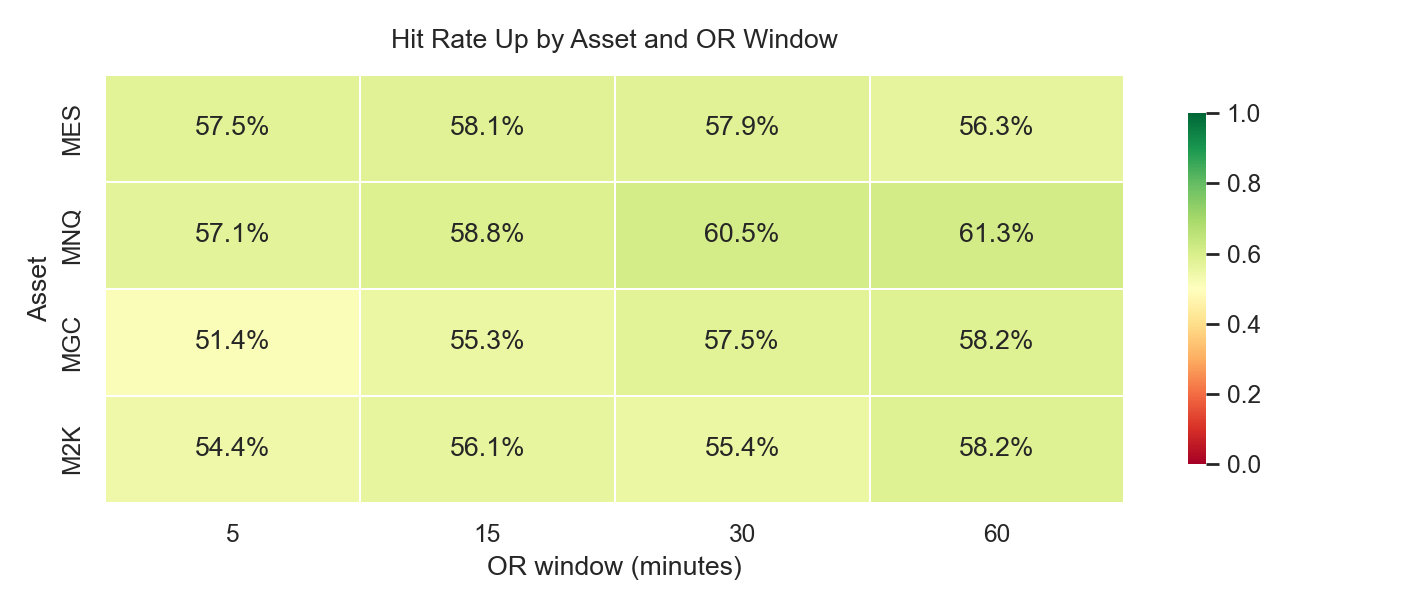

### heatmap_hit_rate_down.png

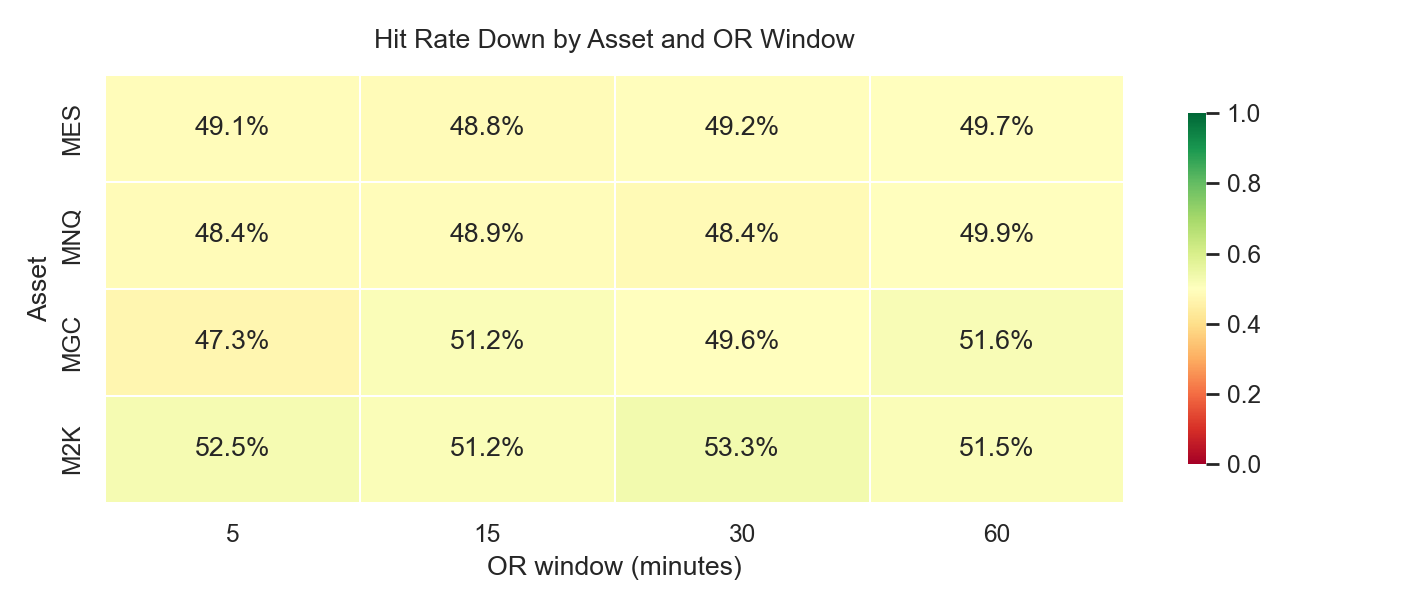

### heatmap_no_breakout_rate.png

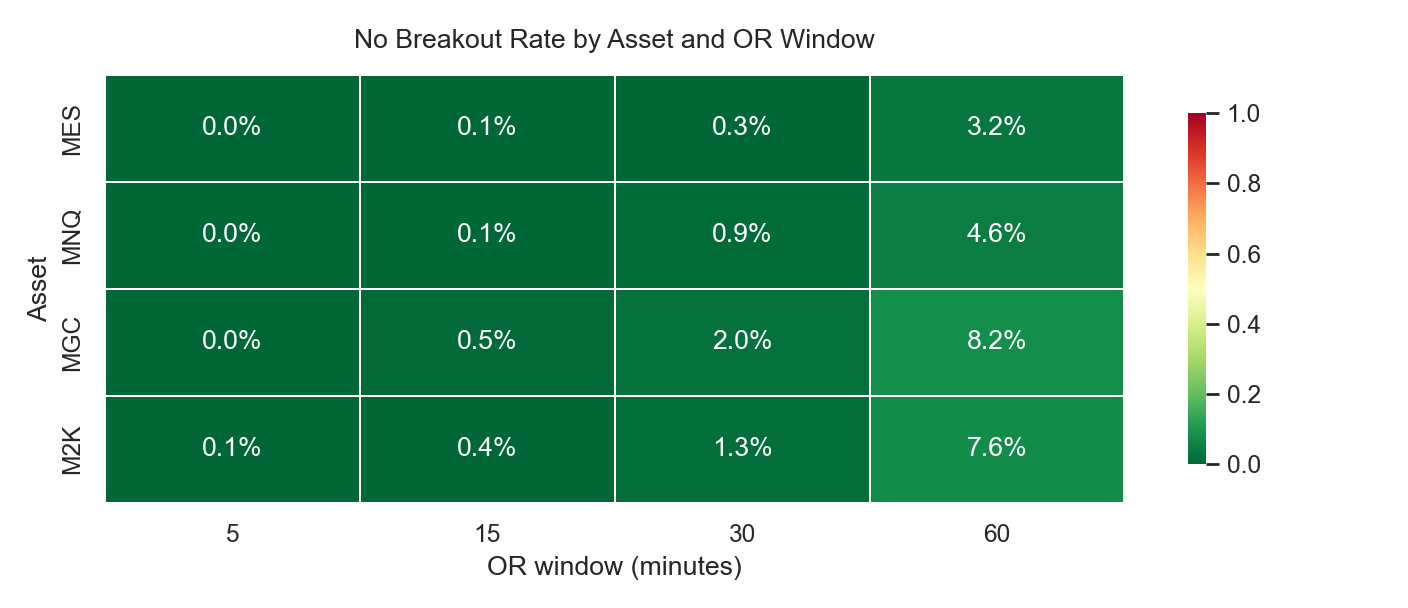

### heatmap_avg_close_extension.png

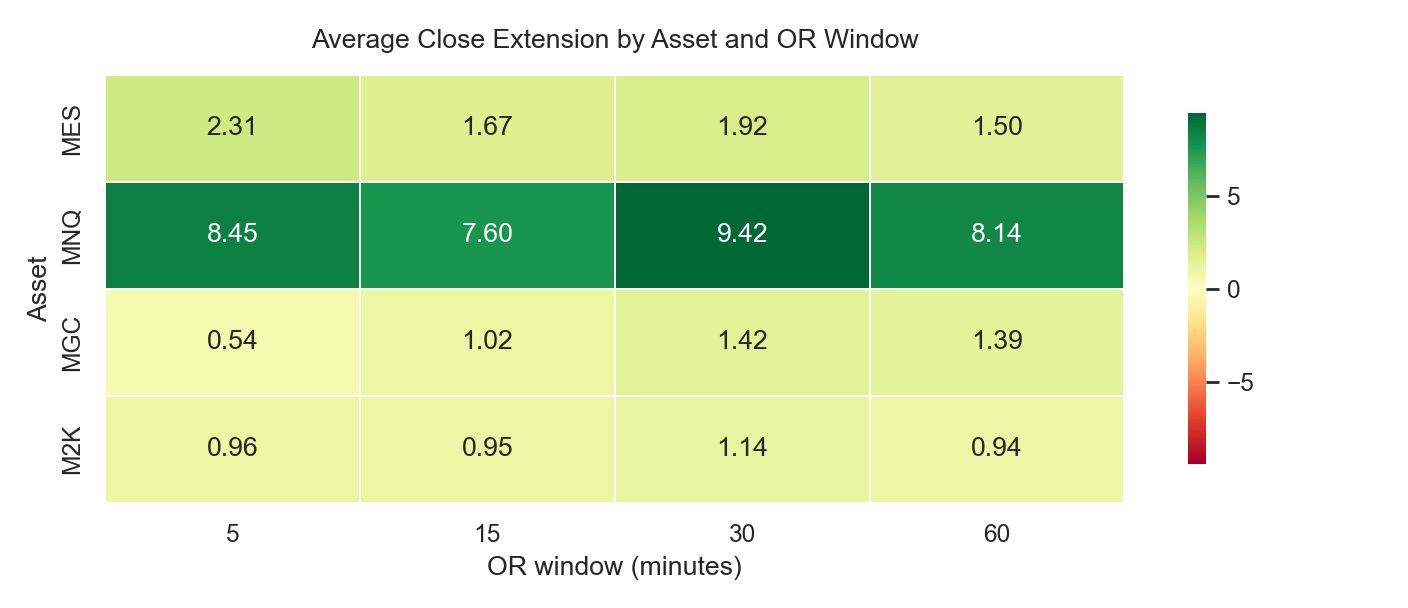

### heatmap_valid_breakouts.png

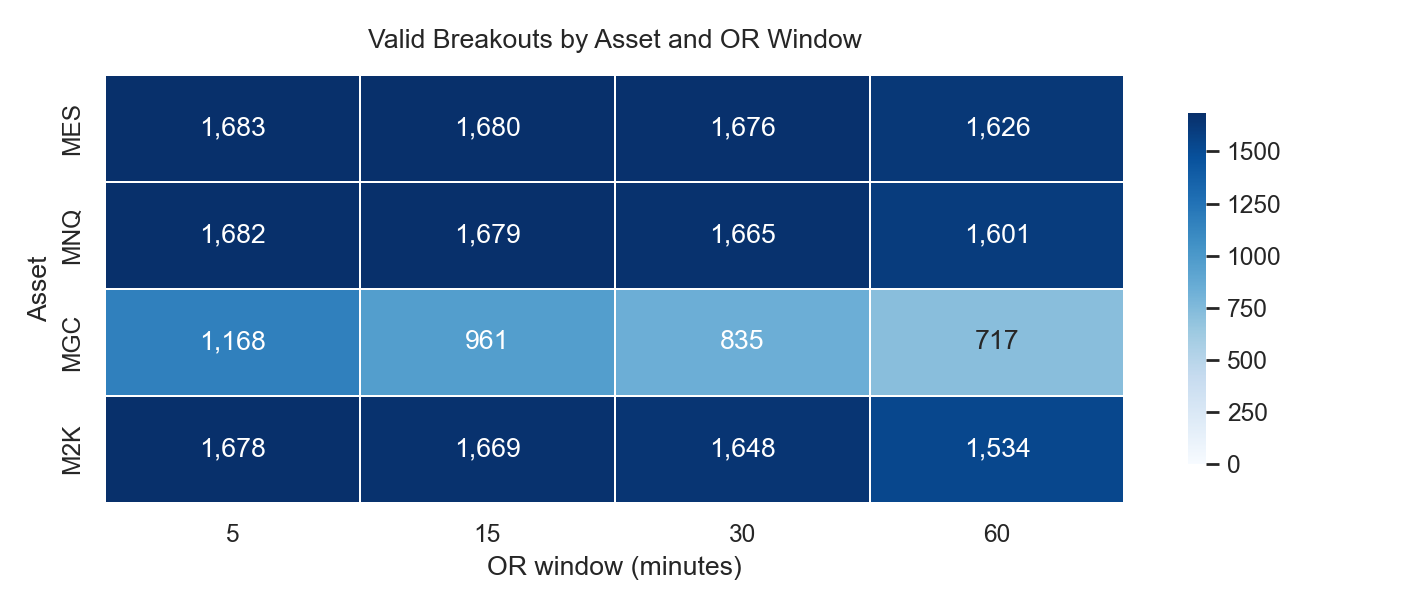

In [4]:
chart_names = [
    "heatmap_hit_rate.png",
    "heatmap_hit_rate_up.png",
    "heatmap_hit_rate_down.png",
    "heatmap_no_breakout_rate.png",
    "heatmap_avg_close_extension.png",
    "heatmap_valid_breakouts.png",
]

for name in chart_names:
    display(Markdown(f"### {name}"))
    display(Image(filename=str(CHARTS_DIR / name)))


## 4) Conclusion simple

In [5]:
answers = build_direct_answers(results, day_level)
display(Markdown(render_direct_answers_markdown(answers)))


## Direct answers

1. Best global hit rate: **MNQ** avec 54.4% sur 6,627 valid breakouts agreges.
2. Best bullish breakout hit rate: **MNQ** avec 59.4% sur 3,451 breakouts up.
3. Best bearish breakout hit rate: **M2K** avec 52.2% sur 3,309 breakouts down.
4. OR window with the best hit rate for each asset:
- M2K: OR 60 min (54.9%, 1,534 valid breakouts).
- MES: OR 30 min (53.8%, 1,676 valid breakouts).
- MGC: OR 60 min (55.1%, 717 valid breakouts).
- MNQ: OR 60 min (56.0%, 1,601 valid breakouts).
5. OR window with the most valid breakouts for each asset:
- M2K: OR 5 min (1,678 valid breakouts, hit rate 53.4%).
- MES: OR 5 min (1,683 valid breakouts, hit rate 53.4%).
- MGC: OR 5 min (1,168 valid breakouts, hit rate 49.3%).
- MNQ: OR 5 min (1,682 valid breakouts, hit rate 52.8%).
6. Most promising asset for a simple directional ORB read: **MNQ** avec l'OR 30 min (54.8% de hit rate, 1,665 breakouts valides, 0.9% de no-breakout).
7. Least noisy asset under this measure: **MNQ** avec 54.4% de hit rate global et une extension mediane de 11.50.
8. Asset with the fewest no-breakout days: **MES** sur l'OR 5 min (0.0% de no-breakout).